In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn import tree
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
import joblib
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
import plotly.colors as colors
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestRegressor
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import tarfile
from astropy.utils.data import download_file
from astropy.table import Table
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

%matplotlib inline

## 0. Retrieve and pre-precess data

Content from [Predicting galaxy redshift via regression on 3D-HST photometry](https://spacetelescope.github.io/hellouniverse/notebooks/hello-universe/Regressing_3D-HST_galaxy_redshift_with_decision_trees/Regressing_3D-HST_galaxy_redshift_with_decision_trees.html)

### 0.0 Download and Examine Dataset

In [4]:
# First, download the 3D-HST catalog from the MAST archive. This dataset is described in Skelton et. al 2014.
file_url = 'https://archive.stsci.edu/missions/hlsp/3d-hst/RELEASE_V4.0/Photometry/3dhst_master.phot.v4.1.tar'
tarfile.open(download_file(file_url, cache=True), "r:").extract('3dhst_master.phot.v4.1/3dhst_master.phot.v4.1.cat', '.')
# Read the combined photmetric catalog into a dataframe via astropy
tab = Table.read('3dhst_master.phot.v4.1/3dhst_master.phot.v4.1.cat', format='ascii').to_pandas()

The data we use for the tutrial is from the [3D-HST survey](https://archive.stsci.edu/prepds/3d-hst/).The dataset contains Hubble Space Telescope (HST) data.The dataset contains standard information such as target id, field name, coordinates, fluxes, errors, and various photometric flags. In addition, there are derived properties such as photometric redshift (z_peak), spectroscopic redshift (z_spec), mass (lmass) and dust extinction in the V band (Av). Let's examine the contents.

In [5]:
tab

,id,field,ra,dec,x,y,z_spec,z_peak,faper_F140W,eaper_F140W,...,flags,f140w_flag,star_flag,use_phot,near_star,nexp_f125w,nexp_f140w,nexp_f160w,lmass,Av
0,1.0,AEGIS,215.222382,53.004185,9590.50,3057.30,-1.0000,0.0100,-82.0410,-82.041000,...,0,0,1,0,0,2,0,3,7.51,1.1
1,2.0,AEGIS,215.096588,52.918053,16473.20,3150.20,-1.0000,0.0100,3.5078,0.074233,...,3,0,0,0,0,4,4,4,5.62,0.1
2,3.0,AEGIS,215.161469,52.959461,13060.10,2982.30,-1.0000,0.2062,-1.9043,-1.904300,...,1,0,0,1,0,2,0,2,9.00,1.1
3,4.0,AEGIS,215.305298,53.052921,5422.80,2692.10,-1.0000,0.0355,-72.3250,-72.325000,...,0,0,0,0,0,1,0,1,4.78,0.4
4,5.0,AEGIS,215.041840,52.871273,19894.60,2834.40,-1.0000,0.3427,1890.5000,0.133300,...,0,1,2,0,1,0,3,0,11.57,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207962,44098.0,UDS,34.363106,-5.122067,14578.84,11076.42,-1.0000,0.1852,188.8200,0.170750,...,0,1,2,0,0,0,3,0,10.21,0.2
207963,44099.0,UDS,34.333569,-5.123219,16343.92,11007.12,-1.0000,0.6716,1.7193,0.129080,...,0,1,2,0,0,0,3,0,8.49,0.7
207964,44100.0,UDS,34.363682,-5.123123,14544.39,11013.01,1.4196,2.7489,1.3829,0.113830,...,0,1,2,0,0,0,4,0,9.08,1.4
207965,44101.0,UDS,34.556389,-5.123040,3028.23,11017.04,-1.0000,1.1716,-99.0000,-99.000000,...,1,0,0,0,0,1,0,2,10.55,1.0


In [6]:
tab.columns

Index(['id', 'field', 'ra', 'dec', 'x', 'y', 'z_spec', 'z_peak', 'faper_F140W',
       'eaper_F140W', 'faper_F160W', 'eaper_F160W', 'f_F606W', 'e_F606W',
       'f_F814W', 'e_F814W', 'f_F125W', 'e_F125W', 'f_F140W', 'e_F140W',
       'f_F160W', 'e_F160W', 'tot_cor', 'kron_radius', 'a_image', 'b_image',
       'flux_radius', 'fwhm_image', 'flags', 'f140w_flag', 'star_flag',
       'use_phot', 'near_star', 'nexp_f125w', 'nexp_f140w', 'nexp_f160w',
       'lmass', 'Av'],
      dtype='object')

### 0.1 Perform Data Cleaning Steps

We need to inspect and clean the data before using it for any model training. To explore the physical parameters of the sample, we plot the spectroscopic redshift vs. the mass.

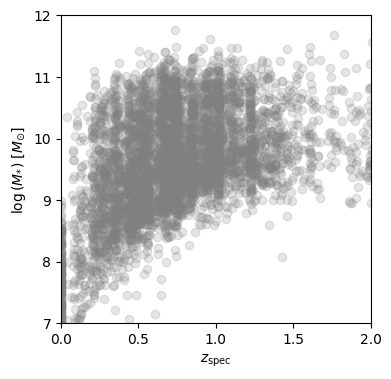

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(tab.z_spec, tab.lmass, alpha=0.2, color='grey')
ax.set_xlim(0, 2)
ax.set_ylim(7, 12)
ax.set_xlabel(r'$z_{\rm spec}$')
ax.set_ylabel(r'$\log{(M_{*})}\,\,[M_{\odot}]$')

plt.show()

By inspection of this plot, we will only keep sources with log(M)>9 to remove sources which do not have complete coverage across redshift. We’re interested in predicting redshift, so our “target” variable will be z_spec. The “features” will be all columns except for the spectroscopic and photometric redshifts.

/var/folders/qj/d2mnyrts1kn7sk7g8_jtz7ww0000gp/T/ipykernel_77718/869721521.py:24: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig = plt.figure(0, [20, 18])


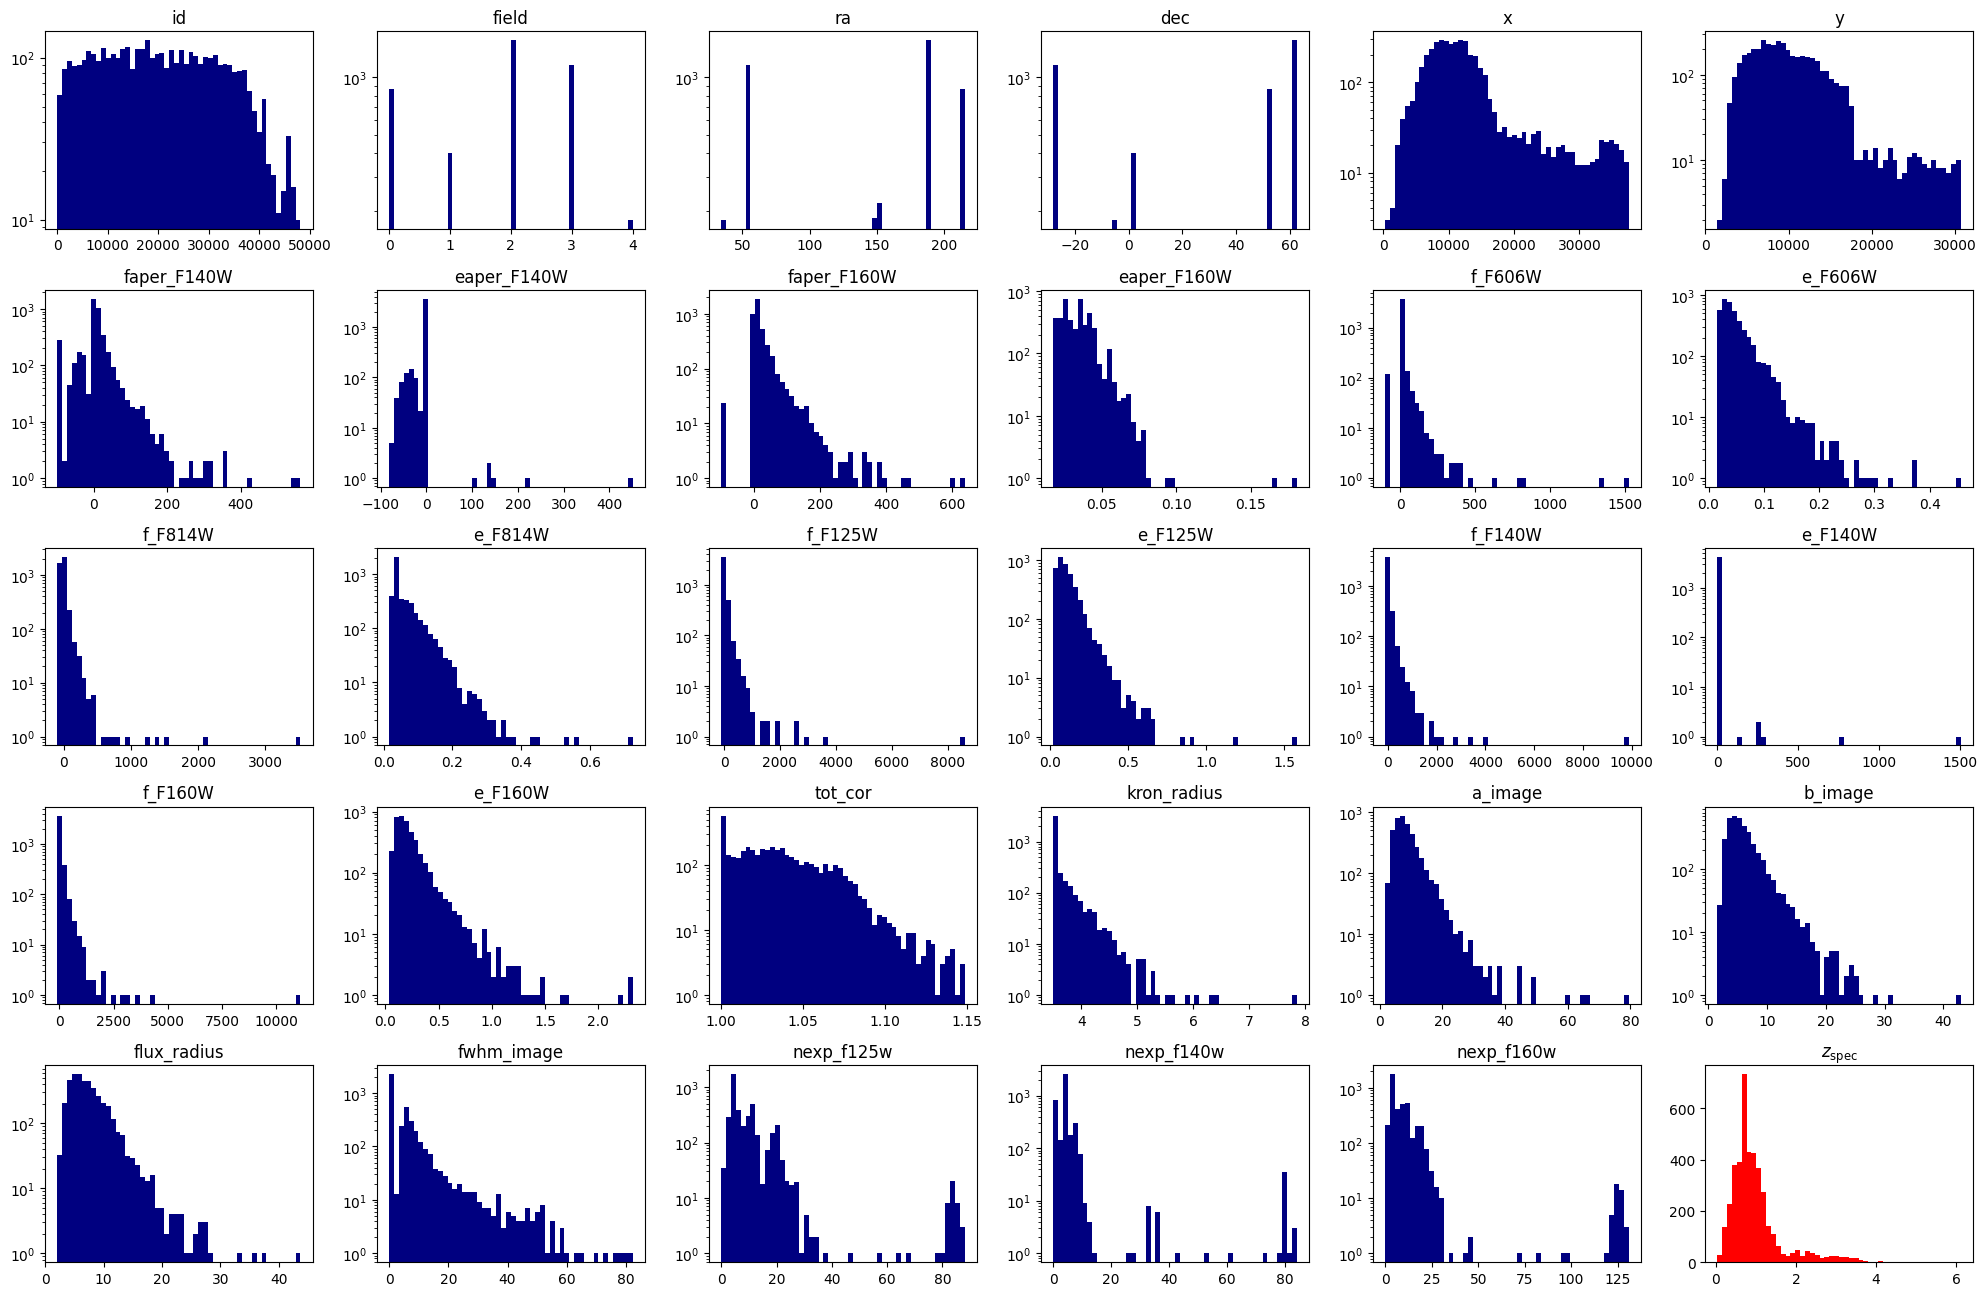

In [8]:
tab = tab[tab.lmass > 9].copy()
target = 'z_spec'
features = [col for col in tab.columns if (col != target)]
fig = plt.figure(0, [20,18])

# The ‘Av’, ‘lmass’ and ‘z_peak’ values were all computed via FAST photometric fit, and so we will exclude them as well. In addition, we will exclude the categorical flag variables (‘flags’, ‘f140w_flag’, ‘star_flag’, ‘use_phot’, ‘near_star’).
features = [col for col in features if (col != 'Av') and (col != 'lmass') and (col != 'z_peak') 
            and (col != 'flags') and (col != 'f140w_flag') and (col != 'star_flag') 
            and (col != 'use_phot') and (col != 'near_star')]

# Next, we will remove sources which have no constraints for our target variable:
tab = tab[(tab[target] > 0)] 

# Next, we will encode the ‘field” variable,
label_encoder = LabelEncoder()
tab['field'] = label_encoder.fit_transform(tab['field'])

# Finally we will impute missing values of photometric errors (set to -99. in the table) by assigning them the median of the distribution:
errors = [col for col in features if (col[:1] == 'e') and (col[-1:] == 'W')]

for error in errors:
    tab[error] = np.where(tab[error] < -90, tab[error].median(), tab[error])

fig = plt.figure(0, [20, 18])

for k, feat in enumerate(features):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(tab[feat], bins=50, log=True, color='navy')
    ax.set_title(feat)

ax = fig.add_subplot(7, 6, len(features)+1)
ax.hist(tab[target], bins=50, color='red')
ax.set_title(r'$z_{\rm spec}$')

plt.tight_layout()
plt.show()

### 0.2 Divide the Data into Train, Test and Validation sets

In [21]:
# Divide the data into train, test and validation sets
X = tab[features].values
y = tab[target].values
indices = np.arange(len(y))

# first reserve 70% of the data for training, 30% for validation
X_train, X_validate, y_train, y_validate, indices_train, indices_validate = train_test_split(X, y, indices, test_size=0.3, random_state=42)

# second, split the validation set in half to obtain validation and test sets. 
X_validate, X_test, y_validate, y_test, indices_validate, indices_test = train_test_split(X_validate, y_validate, indices_validate, test_size=0.5, random_state=42)

### DecisionTreeRegressor

Decision trees can also be applied to regression problems, using the DecisionTreeRegressor class.

As in the classification setting, the fit method will take as argument arrays X and y, only that in this case y is expected to have floating point values instead of integer values:

In [12]:
from sklearn.metrics import mean_squared_error

Decision Tree model with best performance when varying max_depth. MSE = 0.18248568397392925


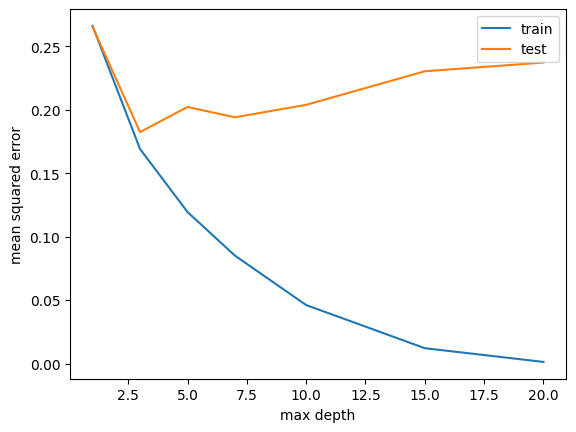

In [41]:
# Fit multiple DT regression models with various values of max_depth
train_mse = []
test_mse = []
max_depths= [1,3,5,7,10,15,20]
for max_depth in max_depths:
    # build model
    regr = DecisionTreeRegressor(max_depth=max_depth)
    regr.fit(X_train, y_train)

    # Get predictions for training and testing data  
    y_train_predict = regr.predict(X_train)
    y_test_predict = regr.predict(X_test)

    # compute training and testing MSE
    train_mse.append(mean_squared_error(y_train, y_train_predict ))
    test_mse.append(mean_squared_error(y_test, y_test_predict))
#    print(f'Train MSE with max_depth {max_depth} = {mean_squared_error(y_train, y_train_predict ):.4f}')
#    print(f'Test MSE with max_depth 10 = {mean_squared_error(y_test, y_test_predict):.4f}')
#    print()

# plot results 
fig,ax=plt.subplots()
ax.plot(max_depths,train_mse,label='train')
ax.plot(max_depths,test_mse, label='test')
ax.set_xlabel('max depth')
ax.set_ylabel('mean squared error') 
ax.legend();

print('Decision Tree model with best performance when varying max_depth. MSE = {}'.format(np.array(test_mse).min()))

The model with a depth of 20 learns the details of the training data to the point that it overfits to the noise. On the other hand, the models with smaller max depth learns the major tendencies in the data well and does not overfit. 

In the plot where are only exploring one hyperparameter that controls tuning the model (max_depth) but there are several other options which could lead to improved perforamnce.  `sklearn` has a tool that can do a grid search across all combinations of several hyperparameters called `RandomizedSearchCV`

In [33]:
hyperparameter_distributions = {
    'max_depth': np.arange(1, 20, 2).astype(int),
    'min_samples_split': np.arange(5, 105, 10).astype(int),
    'min_samples_leaf': np.arange(5, 105, 10).astype(int)
}

In [36]:
from sklearn.model_selection import RandomizedSearchCV
dtree = DecisionTreeRegressor()
random_search = RandomizedSearchCV(
    dtree, 
    param_distributions=hyperparameter_distributions,
    n_iter=100
)

In [37]:
random_search.fit(X_train, y_train.flatten())

RandomizedSearchCV(estimator=DecisionTreeRegressor(), n_iter=100,
                   param_distributions={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_leaf': array([ 5, 15, 25, 35, 45, 55, 65, 75, 85, 95]),
                                        'min_samples_split': array([ 5, 15, 25, 35, 45, 55, 65, 75, 85, 95])})

In [38]:
print(random_search.best_params_)

{'min_samples_split': np.int64(65), 'min_samples_leaf': np.int64(15), 'max_depth': np.int64(7)}


MSE = 0.1532
Decision Tree model with best performance when varying max_depth. MSE = 0.18248568397392925
Decision Tree model with best performance after GridSearch 0.1532


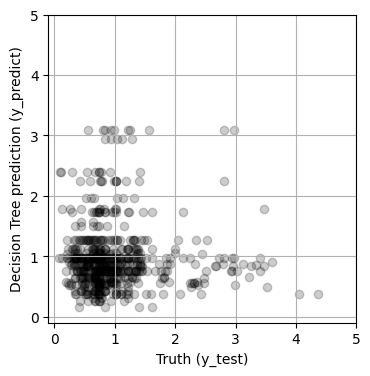

In [42]:
y_predict = random_search.predict(X_test)
print(f'MSE = {mean_squared_error(y_test, y_predict):.4f}')
print('Decision Tree model with best performance when varying max_depth. MSE = {}'.format(np.array(test_mse).min()))
print(f'Decision Tree model with best performance after GridSearch {mean_squared_error(y_test, y_predict):.4f}')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(y_validate, y_predict, alpha=0.2, color='black')
ax.set_aspect('equal')
ax.set_xlim(-0.1, 5)
ax.set_ylim(-0.1, 5)
ax.grid()
ax.set_xlabel('Truth (y_test)')
ax.set_ylabel('Decision Tree prediction (y_predict)')
plt.show()

Ok, great we now have improved our performance compared to where we got to using linear regression yesterday.  Next let's see if Ensemble methods can help us even more.

# Random Forest 

In [43]:
# use the same parameters as the Decision Tree
params = {
    "min_samples_split": 15,
    "min_samples_leaf": 5,
    "max_depth": 15,
}

# Initialize the model
rf = RandomForestRegressor(**params)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, min_samples_split=15)

First Random Forest model performance MSE = 0.1151


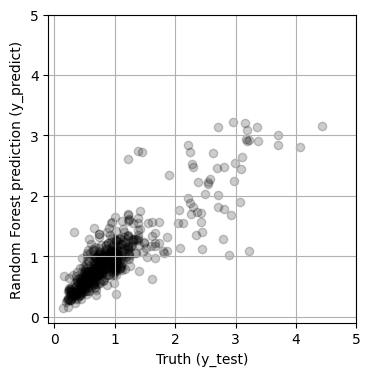

In [45]:
y_predict = rf.predict(X_test)
print(f'First Random Forest model performance MSE = {mean_squared_error(y_test, y_predict):.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(y_test, y_predict, alpha=0.2, color='black')
ax.set_aspect('equal')
ax.set_xlim(-0.1, 5)
ax.set_ylim(-0.1, 5)
ax.grid()
ax.set_xlabel('Truth (y_test)')
ax.set_ylabel('Random Forest prediction (y_predict)')
plt.show()

**add something here where we change number of trees** 

Discuss overfitting in RF

incorporate a bit of training time info 

### Random Forest: Feature importance based on mean decrease in impurity (Gini Importance)

Tutorial is based on https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html.


Feature importances are provided by the fitted attribute feature_importances_ and they are computed as the mean and standard deviation of accumulation of the impurity decrease within each tree.

In [24]:
model = RandomForestRegressor(
    min_samples_leaf=5, random_state=0, n_jobs=N_CORES, n_estimators=50
    ).fit(X, y)
importances = model.feature_importances_
std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)

Let’s plot the impurity-based importance.

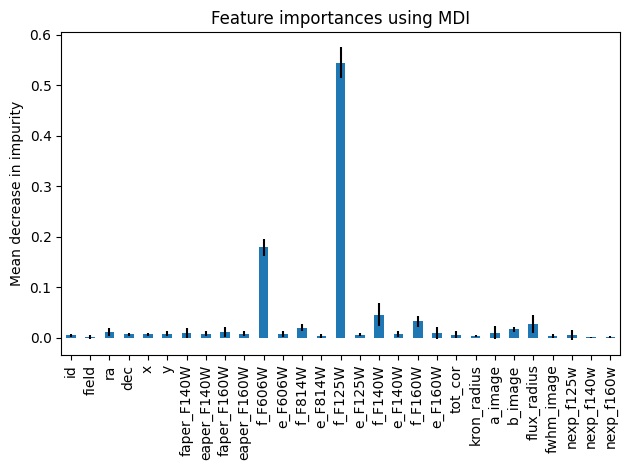

In [26]:
forest_importances = pd.Series(importances, index=features)
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

The most “important” features in this model are the F125W and F606W fluxes. Parameters such as id, ra, dec, x, and y understandably have very little influence on the predictions.

## 3. Gradient Boosting: Xgboost

In [28]:
model = xgboost.XGBRegressor().fit(X_train, y_train)
# We evaluate a model and make predictions as we would do in scikit-learn.
# make predictions
predictions = model.predict(X_test)
print("Mean Absolute Error : " + str(mean_absolute_error(predictions, y_test)))

Mean Absolute Error : 0.22174007258857023


### Model Tuning

XGBoost has a few parameters that can dramatically affect your model's accuracy and training speed. In this tutorial we will run parameter scan on n_estimators and early_stopping_rounds.

N_estimators is the number of gradient boosted trees (Equivalent to number of boosting rounds).

Early_stopping_rounds offers a way to automatically find the ideal value. Early stopping causes the model to stop iterating when the validation score stops improving, even if we aren't at the hard stop for n_estimators.

Here we set a high value for n_estimators and then use early_stopping_rounds to find the optimal time to stop iterating.

In [30]:
model = xgboost.XGBRegressor(n_estimators=100, early_stopping_rounds=2).fit(
                X_train, y_train, 
                eval_set=[(X_test, y_test)], verbose=True)

[0]	validation_0-rmse:0.54135
[1]	validation_0-rmse:0.47124
[2]	validation_0-rmse:0.42886
[3]	validation_0-rmse:0.40026
[4]	validation_0-rmse:0.38975
[5]	validation_0-rmse:0.38133
[6]	validation_0-rmse:0.37351
[7]	validation_0-rmse:0.36878
[8]	validation_0-rmse:0.36759
[9]	validation_0-rmse:0.36529
[10]	validation_0-rmse:0.36679
[11]	validation_0-rmse:0.36474
[12]	validation_0-rmse:0.36437
[13]	validation_0-rmse:0.36269
[14]	validation_0-rmse:0.36202
[15]	validation_0-rmse:0.36084
[16]	validation_0-rmse:0.36253
